In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import pandas as pd

In [6]:
X, y = make_classification(n_samples=100000, n_features=20, n_classes=2, random_state=42)

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
df["target"] = y    
df.head()


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,0.328547,-1.384724,-0.284819,-0.030196,-0.840365,-1.012684,-1.297740,-0.046200,0.744777,-1.843827,...,-0.653045,0.944825,0.732865,-0.198004,-0.664024,-0.230734,-0.355199,-1.165488,2.073555,0
1,0.801869,2.390928,-1.232367,1.144513,-1.031983,0.742784,-1.287784,-0.639615,-1.332604,-0.708368,...,-0.969296,-0.338274,0.064910,-0.904066,-0.245746,1.021368,0.074146,1.120685,1.605930,0
2,-0.674526,-0.261000,-0.464924,-1.495308,-0.203831,0.064322,0.541989,-2.489174,1.023665,-0.316403,...,-0.172466,0.521572,-0.487614,-0.020727,0.034012,-1.341455,-0.368306,-0.068126,0.096521,1
3,-1.188735,1.100929,0.818446,-0.573651,1.331166,1.706128,-0.929116,-0.520684,-0.677726,1.368604,...,1.201381,0.062205,0.436514,1.303629,1.340363,-1.203694,-0.568942,-0.699512,-0.460908,1
4,-1.227908,-0.617620,-0.104353,0.986159,1.319982,1.249342,-1.105068,-0.516500,-2.200517,1.351577,...,1.191881,-1.186905,-1.399522,-0.721840,0.657838,0.139794,-0.212828,-0.702701,-1.022671,1


In [7]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.87105

In [9]:
# hyper parameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['lbfgs', 'liblinear', 'newton-cg']
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5,verbose=1)
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


/Users/rahultiwari/Documents/ml_akila/ml-env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
30 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/rahultiwari/Documents/ml_akila/ml-env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/rahultiwari/Documents/ml_akila/ml-env/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/rahultiwari

,estimator,LogisticRegression()
,param_grid,"{'C': [0.1, 1, ...], 'penalty': ['l1', 'l2'], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [11]:
# best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

# you can re-train the model with the best hyperparameters
best_model = LogisticRegression(**best_params)
best_model.fit(X_train, y_train)

# evaluate the model
y_pred_best = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_best)
print("Accuracy with best hyperparameters:", accuracy)

Best hyperparameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy with best hyperparameters: 0.8712


In [8]:
# I can try different value of C
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
for C in C_values:
    model = LogisticRegression(C=C)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Accuracy for C={C}: {accuracy_score(y_test, y_pred)}")

# re-train 
c=0.1
model = LogisticRegression(C=c)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Accuracy for C={c}: {accuracy_score(y_test, y_pred)}")


Accuracy for C=0.001: 0.83
Accuracy for C=0.01: 0.865
Accuracy for C=0.1: 0.865
Accuracy for C=1: 0.855
Accuracy for C=10: 0.855
Accuracy for C=100: 0.855
Accuracy for C=0.1: 0.865


Model coefficients: [[ 0.08189599 -0.44234932  0.18798493  0.07930494 -0.01585978  1.40333077
  -0.07451354 -0.01730603 -0.02891493  0.01526517  0.16647772  0.36121465
   0.02507991  0.09508326 -0.42083276  0.05603839  0.05786195 -0.11724914
  -0.66935842  0.08596286]]
Model intercept: [0.10100446]


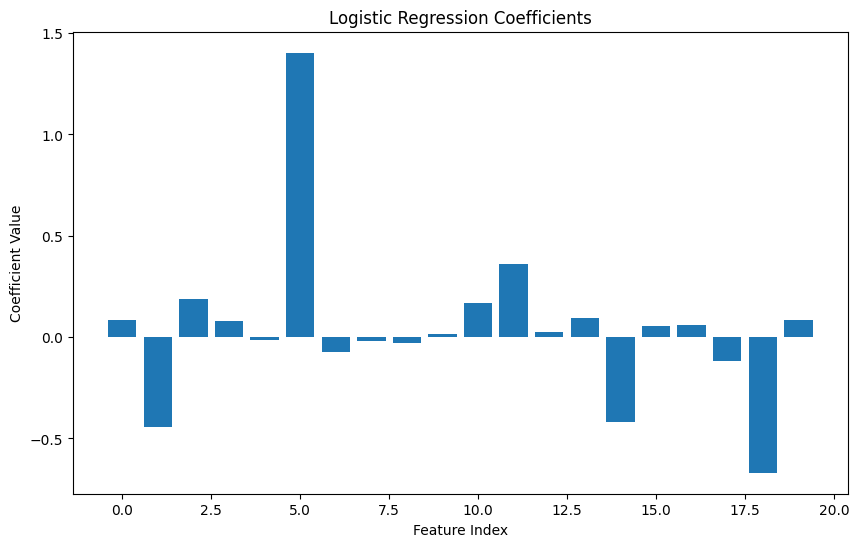

In [ ]:
# model coefficients
coefficients = model.coef_
intercept = model.intercept_
print("Model coefficients:", coefficients)
print("Model intercept:", intercept)


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(range(len(coefficients[0])), coefficients[0])
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Logistic Regression Coefficients")
plt.show()

# how to interpret the coefficients?
# The coefficients represent the change in the log-odds of the target variable for a one-unit increase in the feature.
# A positive coefficient indicates that as the feature increases, the likelihood of the target being 1 increases.
# A negative coefficient indicates that as the feature increases, the likelihood of the target being 1 decreases.

In [ ]:
# https://medium.com/@jairiidriss/what-is-hyperparameter-optimization-477c15fe8cbe
#https://www.analyticsvidhya.com/blog/2021/05/bayesian-optimization-bayes_opt-or-hyperopt/